## Lab 3: Kaj and Drew

AI Statement: We used generative AI with very specific prompts to create the functions that took an image, compressed it, and then recreated the image. AI also helped us quickly format the display function to show the images in one row. We did not use gen AI for the actual analysis of the photos.

We are going to start by taking all of the files of faces and flatten all 2D images to a 1D array.

This gives use 3279 rows which is the number of pictures as well as 16129 (127^2)

In [5]:
import os
import numpy as np
from PIL import Image

# Directory where your images are stored
image_dir = './cropped_faces'

# Function to load and flatten the images
def load_and_flatten_images(image_dir):
    image_list = []
    
    # Loop through all files in the directory
    for filename in sorted(os.listdir(image_dir)):
        if filename.endswith('.jpg') or filename.endswith('.png'):  # Adjust file types as needed
            # Open the image using PIL (Pillow)
            img = Image.open(os.path.join(image_dir, filename))
           
            # Ensure the image is in grayscale (mode 'L' for grayscale)
            img = img.convert('L')
           
            # Resize image to (128, 128) if it's not already
            img = img.resize((127, 127))
           
            # Convert image to numpy array and flatten it to 1D
            img_array = np.array(img).flatten()
           
            # Append the flattened image to the list
            image_list.append(img_array)
   
    # Convert the list of flattened images to a numpy array
    image_matrix = np.array(image_list)
   
    return image_matrix

# Load and flatten all images
image_matrix = load_and_flatten_images(image_dir)

# Print the shape of the resulting matrix (should be (num_images, 16129))
print(f"Shape of the image matrix: {image_matrix.shape}")

Shape of the image matrix: (3279, 16129)


### 1D to Image
This code takes the 1D array of the flattened images and turns them back into an image. We printed the first 5 MIDN

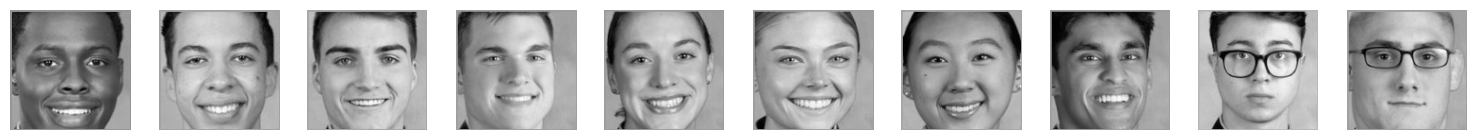

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def display_image_from_row(flat_row, image_size=(127, 127)):
    """
    Given a flattened row (1D array), reshape it to the image size and display the image.
    
    :param flat_row: The flattened image (1D array).
    :param image_size: Tuple specifying the original image size, default is (128, 128).
    """
    # Reshape the flat row back into the original 2D image shape
    image = flat_row.reshape(image_size)
    
    # Display the image using matplotlib
    plt.imshow(image, cmap='gray')  # 'gray' colormap for grayscale images
    plt.axis('off')  # Turn off axis labels
    plt.show()

# Example usage:
# Assuming image_matrix is the matrix you generated earlier and you want to display the first image row
display_images_on_one_line(image_matrix, [0,1,2,3,4,5,6,7,8,9])

### Singular Values
As seen below, the singular values quickly become small. This indicates that after a certain point, the singular values are not very defining for the matrix. However, more testing with outputting images is needed to know at what point do these values become vital. It is hard to apply a numerical value to this "drop off"

test
Singular values: [1.06166378e+06 1.10442669e+05 7.81789201e+04 ... 2.84548495e+02
 2.79524702e+02 2.76133249e+02]


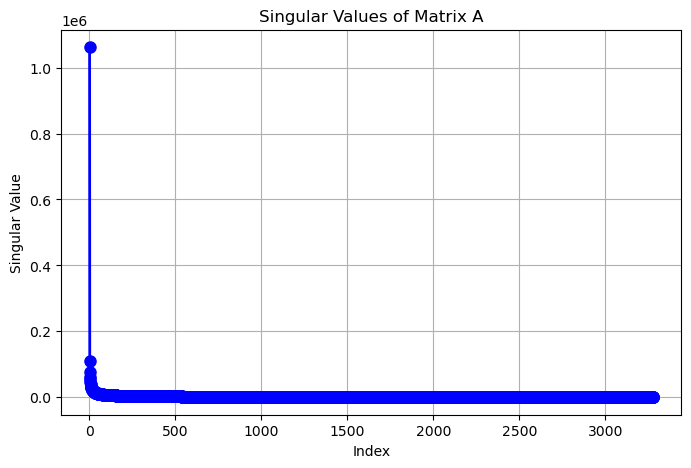

Rank of the matrix: 3279


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Example matrix A (you can replace this with your matrix)
A = image_matrix

# Compute singular values using SVD
U, sigma, Vt = np.linalg.svd(A)
print("test")

# Print singular values
print("Singular values:", sigma)

#
# Plot singular values
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(sigma)+1), sigma, 'bo-', linewidth=2, markersize=8)
plt.title("Singular Values of Matrix A")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.grid(True)
plt.show()

# Calculate the numerical rank of the matrix
# Using a tolerance to account for floating point precision
tol = 1e-10
rank = np.sum(sigma > tol)
print(f"Rank of the matrix: {rank}")

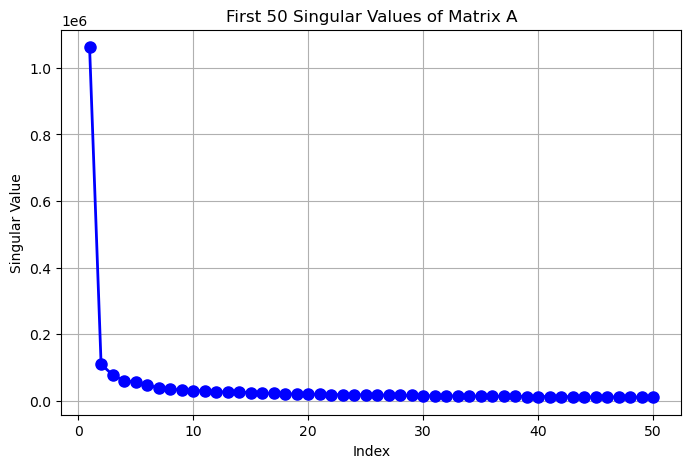

In [8]:
# Number of singular values to plot
num_values_to_plot = 50

# Slice the singular values array to get first 10 (or less if not enough)
singular_values_to_plot = sigma[:num_values_to_plot]

# Plot the first 10 singular values
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(singular_values_to_plot) + 1), singular_values_to_plot, 'bo-', linewidth=2, markersize=8)
plt.title("First " + str(num_values_to_plot) + " Singular Values of Matrix A")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.grid(True)
plt.show()

### Low-rank Approx Start
This code crops the matrices based off a decided k value. Our estimated value of 30 was off as many features are missing. More testing in the next code block.

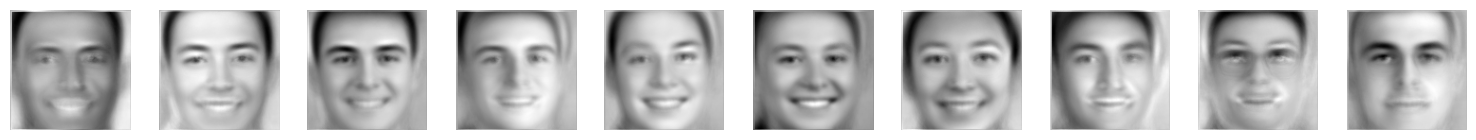

In [20]:
# Suppose you already have U, s, Vt from SVD:
# U: shape (m, m)
# s: shape (min(m, n),)  # singular values vector
# Vt: shape (n, n)

# Example k (number of components to keep)
k = 30 # set this to your desired number of components

# Crop U to first k columns
Ucropped = U[:, :k]

# Crop singular values vector s to first k values
Scropped = sigma[:k]

# Crop Vt to first k rows
Vcropped = Vt[:k, :]

# Convert Scropped (vector) into a diagonal matrix
Scropped_matrix = np.diag(Scropped)

# Multiply to get the reconstructed matrix
ANew = np.dot(Ucropped, np.dot(Scropped_matrix, Vcropped))

display_images_on_one_line(ANew, [0,1,2,3,4,5,6,7,8,9])

### Unique Faces to Find Ideal K
Here we chose a list of MIDN with very different faces. We looked to see at what k values did certain features expose themselves. First is the original pictures of our unique middies. 

In [10]:
unique_list = ["./cropped_faces/face_260300.jpg", "./cropped_faces/face_274146.jpg", "./cropped_faces/face_274218.jpg", "./cropped_faces/face_274266.jpg", "./cropped_faces/face_274008.jpg", "./cropped_faces/face_277050.jpg", "./cropped_faces/face_280012.jpg", "./cropped_faces/face_286966.jpg", "./cropped_faces/face_271050.jpg"]                #dark, F, smile    F, glasses, smile   black, M, smile   white,M,smi,glass   white, M, no-smi  F,smile,white         dark,M, no-smi   glass, M, no-smi     F, smile, tilt

Indices of the files in unique_list: [60, 1309, 1761, 1783, 1795, 1802, 2221, 2236, 3252]


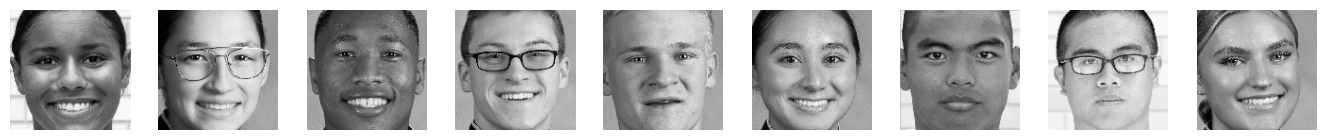

In [18]:
# Your list of unique file paths
unique_list = ["./cropped_faces/face_260300.jpg", "./cropped_faces/face_274146.jpg", "./cropped_faces/face_274218.jpg", "./cropped_faces/face_274266.jpg", "./cropped_faces/face_274008.jpg", "./cropped_faces/face_277050.jpg", "./cropped_faces/face_280012.jpg", "./cropped_faces/face_286966.jpg", "./cropped_faces/face_271050.jpg"]

# Directory where your images are stored
image_dir = './cropped_faces'

# Get a sorted list of all .jpg files in the directory
sorted_dir_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg')])

# Get the list of filenames from your unique_list for comparison
unique_filenames = [os.path.basename(f) for f in unique_list]

# Find the indices of each unique file within the sorted directory list
indices = [sorted_dir_files.index(f) for f in unique_filenames]

# Print the found indices
print(f"Indices of the files in unique_list: {sorted(indices)}")

display_images_on_one_line(image_matrix, indices)

In [22]:
def display_images_on_one_line(image_matrix, indices):
    """
    Displays multiple images on a single horizontal line.
    
    Args:
        image_matrix (np.array): The matrix of flattened image data.
        indices (list): A list of row indices to display from the matrix.
    """
    num_images = len(indices)
    
    # Create a figure and a set of subplots
    # The figure will have 1 row and num_images columns
    fig, axes = plt.subplots(1, num_images, figsize=(1.5 * num_images, 1.5))
    
    # If there's only one image, axes will be a single object, not an array
    if num_images == 1:
        axes = [axes]
    
    # Loop through the indices and plot each image in a subplot
    for i, idx in enumerate(indices):
        # Reshape the flattened image back into a 2D array (127x127)
        img_reshaped = image_matrix[idx].reshape((127, 127))
        
        # Display the image on the current subplot
        axes[i].imshow(img_reshaped, cmap='gray')
        axes[i].axis('off')  # Hide the axes to make the display cleaner
        
    plt.tight_layout()  # Adjust subplot parameters for a tight layout
    plt.show()  # Display the plot

#display_images_on_one_line(ANew, indices)


## First exploration of K:
We picked a set of faces that offered diverse characteristics compared to the "generic" midshipmen that gets printed out when k = 1. We chose variety in the level of smileyness, glasses, head tilt, skin color, etc. We then created a loop to print out the same images with varying K's. Our goal was to figure out at what "K" value do the faces become distinct and recognizable. The K values between 1 and 200 are the most formative and provide the most identifying information regarding the faces of the midshipmen. At 600, the noise really disappears. Our next step is to further explore the k values between 1 and 200 to see where the transition really takes place.

k: 1


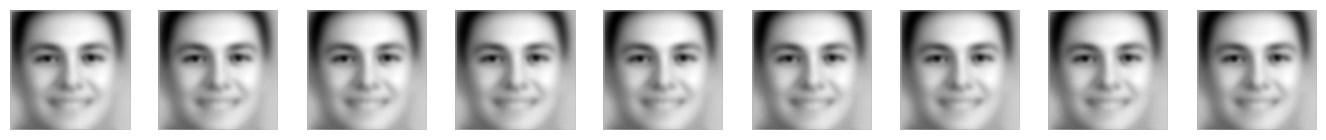

k: 201


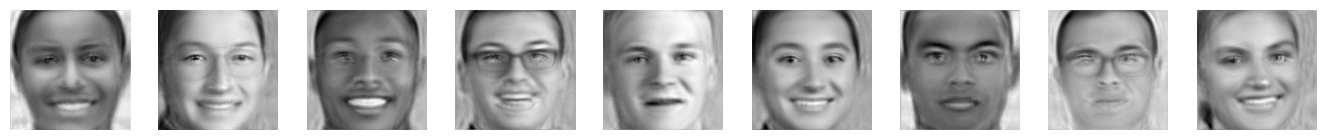

k: 401


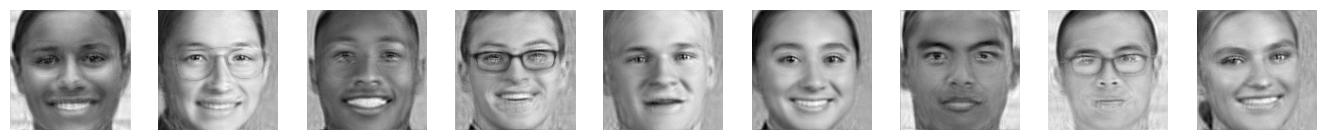

k: 601


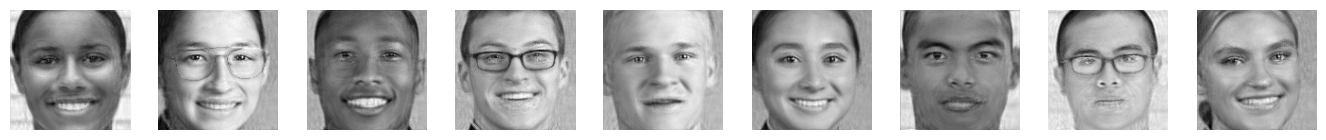

k: 801


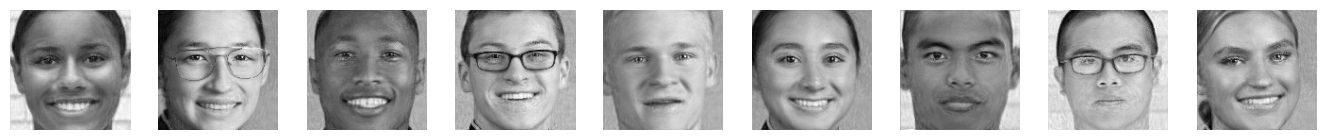

k: 1001


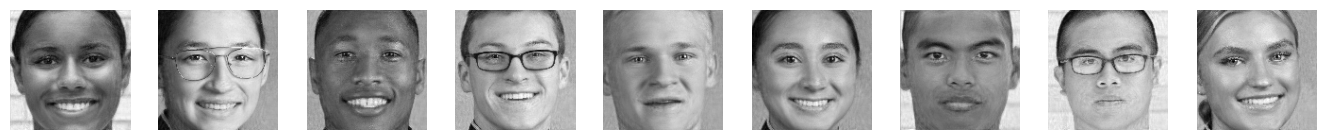

In [23]:
# Example k (number of components to keep)
k = 1 # set this to your desired number of components

while k < 1200:
    # Crop U to first k columns
    Ucropped = U[:, :k]
    
    # Crop singular values vector s to first k values
    Scropped = sigma[:k]
    
    # Crop Vt to first k rows
    Vcropped = Vt[:k, :]
    
    # Convert Scropped (vector) into a diagonal matrix
    Scropped_matrix = np.diag(Scropped)
    
    # Multiply to get the reconstructed matrix
    ANew = np.dot(Ucropped, np.dot(Scropped_matrix, Vcropped))

    print("k: " + str(k))
    display_images_on_one_line(ANew, indices)

    k += 200

### Analyzing K Values from 1 to 200: The Important Factors
We started by looking at 1-10 to see which features are the most important. The first 10 showed changes and specifications in skin tone, face shape, smileyness, and eyeshape. Surprisingly, glasses did not come into play until k = 60. This surprised us since glasses are usually a very prevalent feature on someone's face. Gender, glasses, and head tilt started to become obvious around k = 60. Identities could roughly be determined by K = 40 however these images were not clear. There is one midshipman who has lighter glasses, and her glasses did not really show up K = 300. This means that the kind of glasses has an impact on how early they can be detected. We also saw this in the smiles. The "stronger" the smile, the earlier it appeared with changing k values. Despite defining features, there is ja lot of noise in the photo until much larger K values (like K = 400-500). Despite defining features, there is ja lot of noise in the photo until much larger K values (like K = 400-500).

k: 1


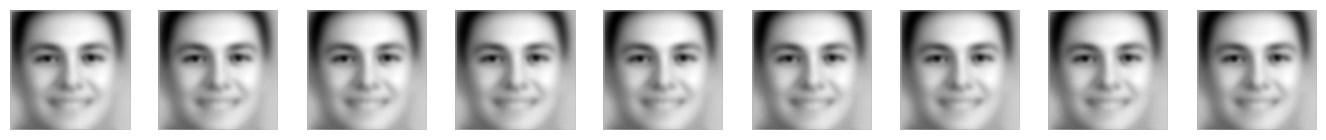

k: 2


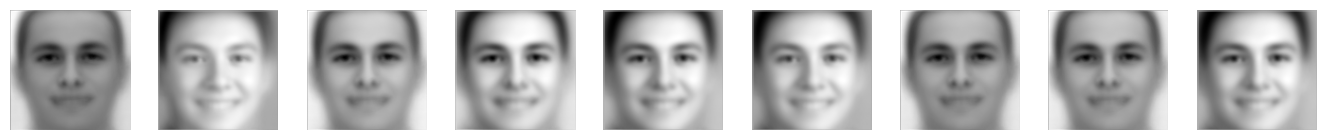

k: 3


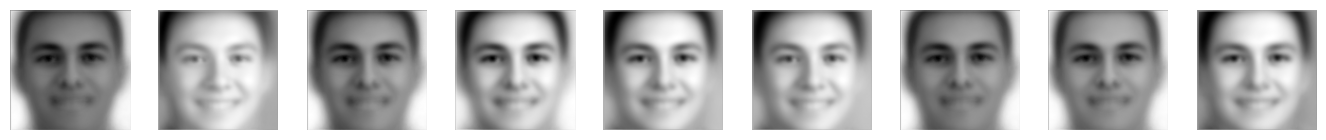

k: 4


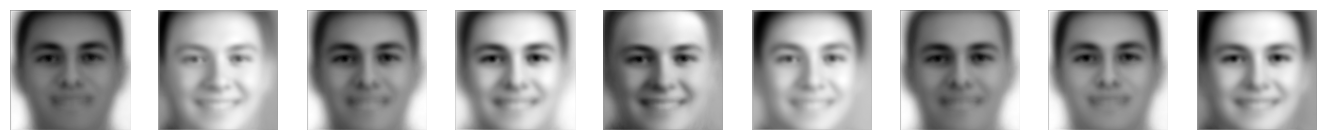

k: 5


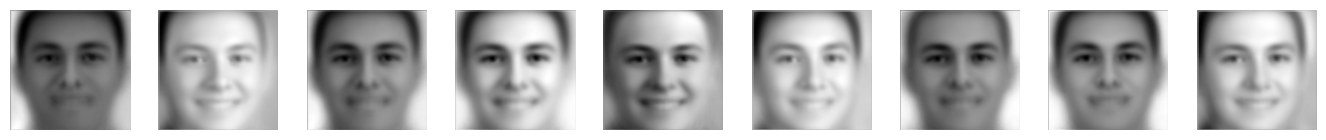

k: 6


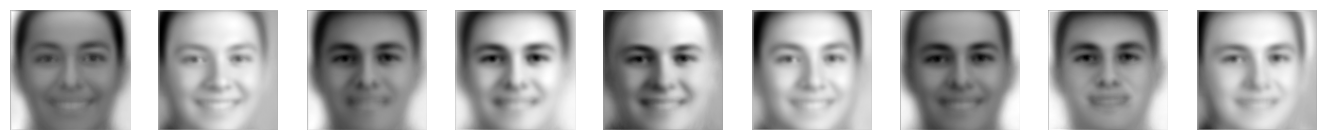

k: 7


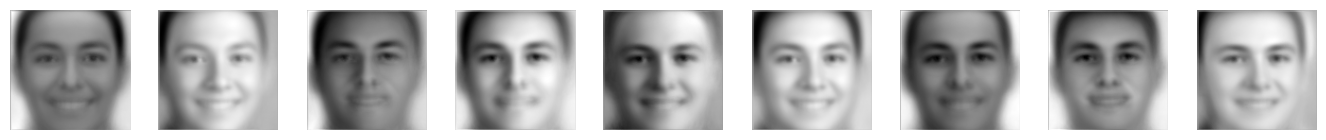

k: 8


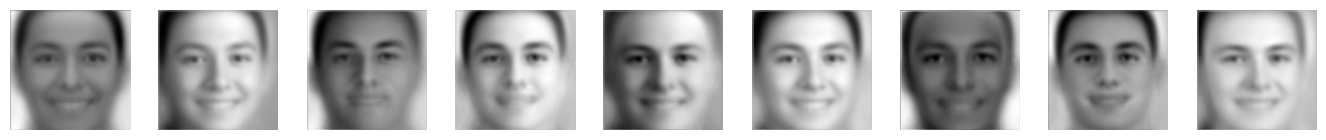

k: 9


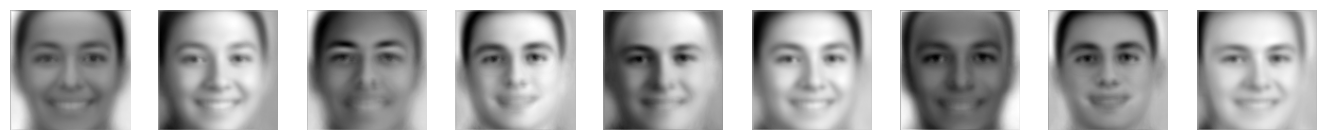

In [15]:
# Example k (number of components to keep)
k = 1 # set this to your desired number of components

while k < 10:
    # Crop U to first k columns
    Ucropped = U[:, :k]
    
    # Crop singular values vector s to first k values
    Scropped = sigma[:k]
    
    # Crop Vt to first k rows
    Vcropped = Vt[:k, :]
    
    # Convert Scropped (vector) into a diagonal matrix
    Scropped_matrix = np.diag(Scropped)
    
    # Multiply to get the reconstructed matrix
    ANew = np.dot(Ucropped, np.dot(Scropped_matrix, Vcropped))

    print("k: " + str(k))
    display_images_on_one_line(ANew, indices)

    k += 1

k: 1


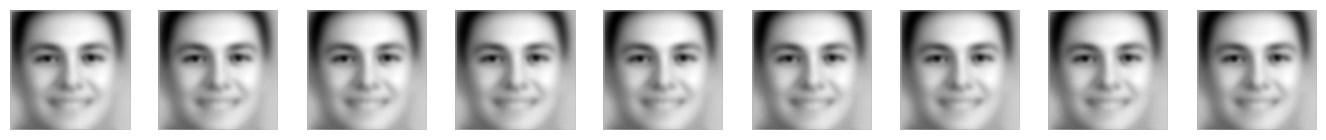

k: 21


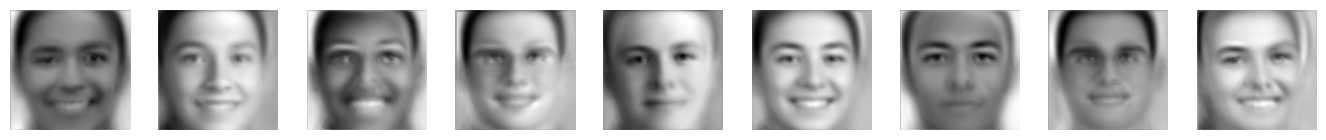

k: 41


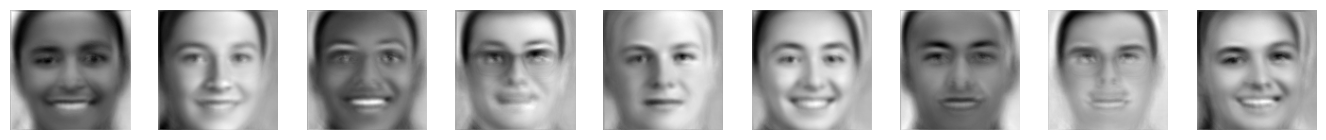

k: 61


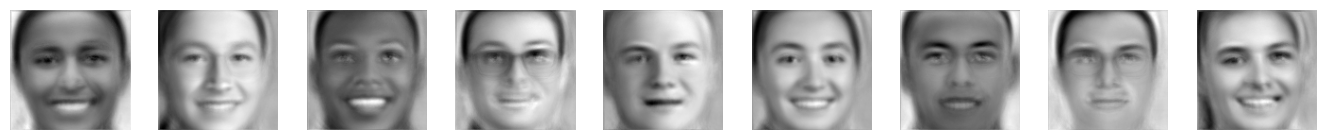

k: 81


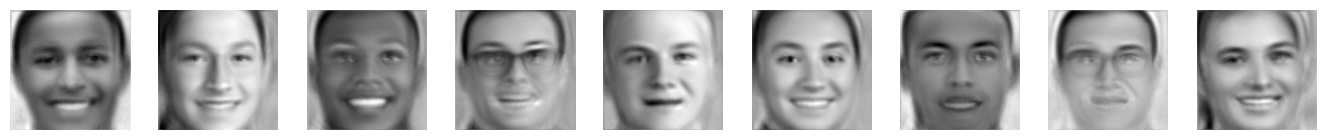

k: 101


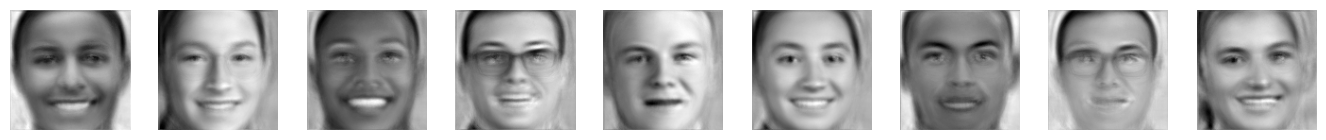

k: 121


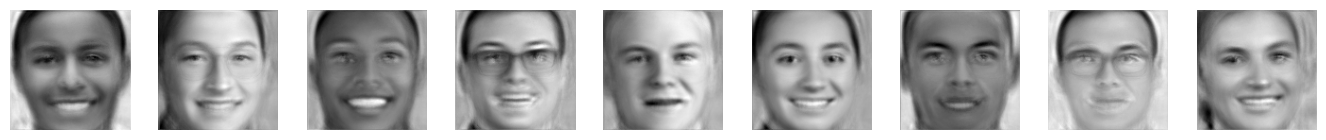

k: 141


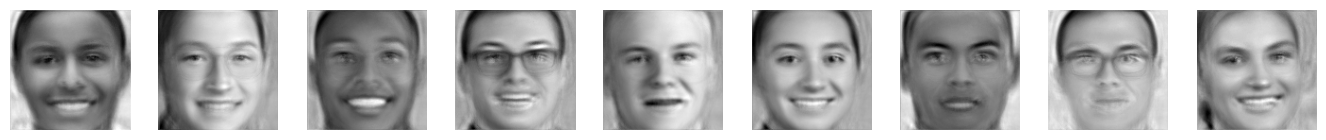

k: 161


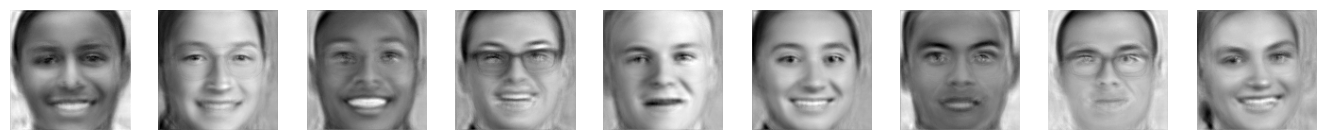

k: 181


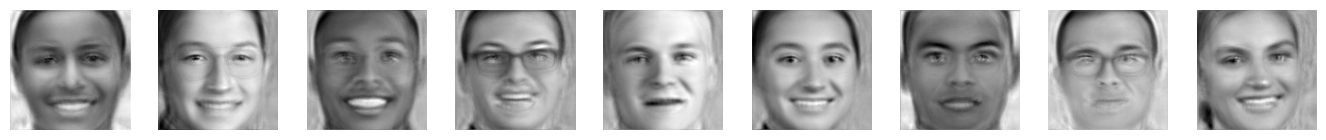

k: 201


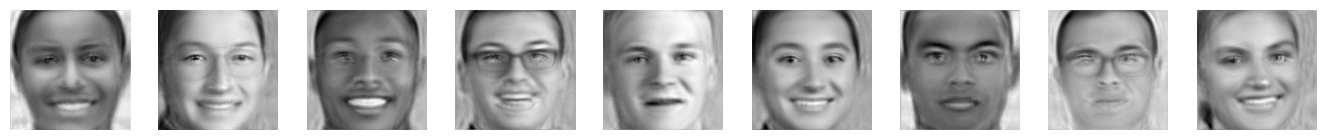

In [17]:
# Example k (number of components to keep)
k = 1 # set this to your desired number of components

while k < 210:
    # Crop U to first k columns
    Ucropped = U[:, :k]
    
    # Crop singular values vector s to first k values
    Scropped = sigma[:k]
    
    # Crop Vt to first k rows
    Vcropped = Vt[:k, :]
    
    # Convert Scropped (vector) into a diagonal matrix
    Scropped_matrix = np.diag(Scropped)
    
    # Multiply to get the reconstructed matrix
    ANew = np.dot(Ucropped, np.dot(Scropped_matrix, Vcropped))

    print("k: " + str(k))
    display_images_on_one_line(ANew, indices)

    k += 20